# Step 1: Data Collection and Initial Analysis

This notebook demonstrates the initial stage of the pipeline:
- Fetching QRNG data
- Basic statistical validation
- Preparing data for downstream processing


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chisquare
from scipy.stats import pearsonr

In [ ]:
import requests
import time

def fetch_qrng_bytes(num_bytes, api_url="https://lfdr.de/qrng_api/qrng", chunk_size=1024):
    """
    Fetch num_bytes of quantum random data from the QRNG API.
    Properly parses JSON response and converts hex string to bytes.
    Returns bytearray of the data.
    """
    data = bytearray()
    bytes_fetched = 0

    while bytes_fetched < num_bytes:
        to_request = min(chunk_size, num_bytes - bytes_fetched)
        params = {
            "length": to_request,
            "format": "HEX"  # Use HEX format, not BINARY
        }
        try:
            resp = requests.get(api_url, params=params, timeout=10)
            resp.raise_for_status()

            # Parse JSON response
            json_data = resp.json()
            hex_string = json_data['qrn']

            # Convert hex string to bytes
            chunk = bytes.fromhex(hex_string)
            data.extend(chunk)
            bytes_fetched += len(chunk)

            print(f"Fetched {bytes_fetched}/{num_bytes} bytes", end='\r')
            time.sleep(0.1)

        except Exception as e:
            print(f"\nError at bytes_fetched={bytes_fetched}: {e}")
            print("Sleeping for a bit then retrying...")
            time.sleep(5)

    print()
    return data

In [ ]:
# Fetch 1 million bytes (adjust as needed)
binary_data = fetch_qrng_bytes(1000000, chunk_size=100000)  # Start with smaller amount for testing

for i in range(29):
  binary_data.extend(fetch_qrng_bytes(1000000, chunk_size=100000))

# Save to file
filename = "qrng_data_corrected_30mill_pt2.bin"
with open(filename, "wb") as f:
    f.write(binary_data)

print(f"Saved {len(binary_data)} bytes to {filename}")

In [ ]:
# Load and verify
filename = "/content/qrng_data_corrected_10mill.bin"
with open(filename, "rb") as f:
    binary_data = f.read()
byte_array = np.frombuffer(binary_data, dtype=np.uint8)
print(f"\nTotal bytes: {len(byte_array)}")
print(f"First 20 values: {byte_array[:20]}")


Total bytes: 11000000
First 20 values: [196  40 159 162 251  98 142   0   7 152 163  83 129 200   3 229 160 175
  97  47]


/tmp/ipython-input-681899384.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


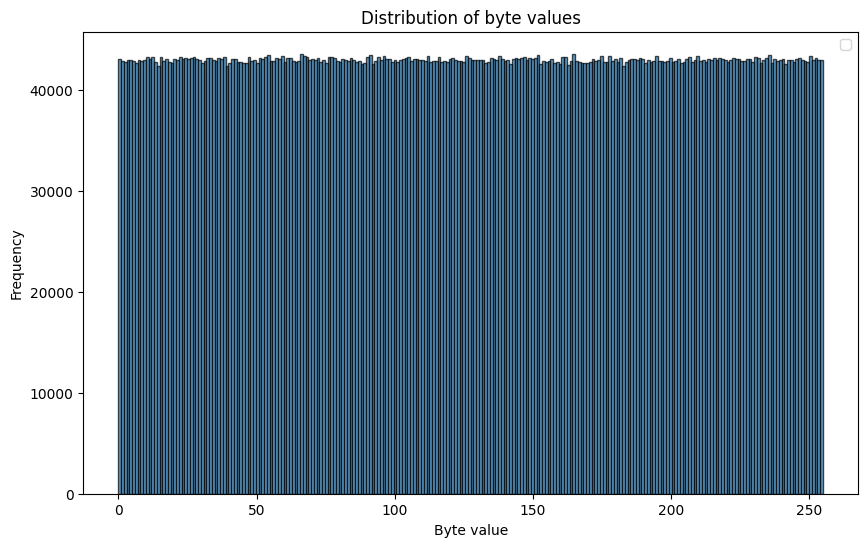

In [ ]:
# Distribution Histogram
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.hist(byte_array, bins=256, range=(0, 255), edgecolor='black', alpha=0.7)
plt.title("Distribution of byte values")
plt.xlabel("Byte value")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [ ]:
#Chi-square test
from scipy.stats import chisquare
observed = np.bincount(byte_array, minlength=256)
expected = np.full(256, len(byte_array)/256)
chi2, p_value = chisquare(observed, expected)
print(f"\nChi-square test for uniformity:")
print(f"p-value: {p_value:.4f} (should be > 0.05 for random data)")


Chi-square test for uniformity:
p-value: 0.2259 (should be > 0.05 for random data)


In [ ]:
#Autocorrelation test
from scipy.stats import pearsonr
print("\nAutocorrelation test:")
lags = [1, 2, 4, 8, 16, 32, 64, 128]
for lag in lags:
    if lag < len(byte_array):
        corr, _ = pearsonr(byte_array[:-lag], byte_array[lag:])
        print(f"Lag {lag}: correlation = {corr:.4f} (should be near 0)")


Autocorrelation test:
Lag 1: correlation = -0.0002 (should be near 0)
Lag 2: correlation = -0.0006 (should be near 0)
Lag 4: correlation = -0.0003 (should be near 0)
Lag 8: correlation = -0.0003 (should be near 0)
Lag 16: correlation = 0.0001 (should be near 0)
Lag 32: correlation = -0.0000 (should be near 0)
Lag 64: correlation = 0.0001 (should be near 0)
Lag 128: correlation = -0.0004 (should be near 0)
